In [22]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, roc_curve, auc

from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
val_df = pd.read_csv("data/val.csv")

In [24]:
label = 'label'

train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [25]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [26]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=64, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=64, out_features=1, bias=True)
)


In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
THRESHOLD = 0.5

In [28]:
best_loss = float('inf')
patience = 10
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model_phase_2.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.6825 Accuracy: 0.5697
Valid - Loss: 0.6690 Accuracy: 0.6454
----------------------------------------
Epoch: 1
Train - Loss: 0.6598 Accuracy: 0.6468
Valid - Loss: 0.6476 Accuracy: 0.7349
----------------------------------------
Epoch: 2
Train - Loss: 0.6389 Accuracy: 0.6965
Valid - Loss: 0.6276 Accuracy: 0.7487
----------------------------------------
Epoch: 3
Train - Loss: 0.6238 Accuracy: 0.7098
Valid - Loss: 0.6126 Accuracy: 0.7522
----------------------------------------
Epoch: 4
Train - Loss: 0.6070 Accuracy: 0.7257
Valid - Loss: 0.5981 Accuracy: 0.7556
----------------------------------------
Epoch: 5
Train - Loss: 0.5950 Accuracy: 0.7330
Valid - Loss: 0.5847 Accuracy: 0.7539
----------------------------------------
Epoch: 6
Train - Loss: 0.5826 Accuracy: 0.7404
Valid - Loss: 0.5752 Accuracy: 0.7590
----------------------------------------
Epoch: 7
Train - Loss: 0.5749 Accuracy: 0.7404
Valid - Loss: 0.5673 Accuracy: 0.7590
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.7698
Precision : 0.7297
Recall    : 0.5347
F1 Score  : 0.6171

Confusion Matrix:
 [[340  40]
 [ 94 108]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.78      0.89      0.84       380
         1.0       0.73      0.53      0.62       202

    accuracy                           0.77       582
   macro avg       0.76      0.71      0.73       582
weighted avg       0.76      0.77      0.76       582



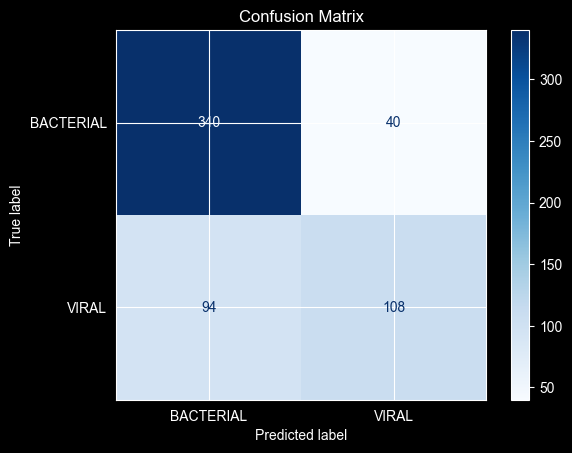

In [29]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])

In [30]:
model.load_state_dict(torch.load("../model_repository/pneumonia_model_phase_2.pth"))
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
j_scores = tpr - fpr
best_threshold = roc_thresholds[np.argmax(j_scores)]

print("Chosen threshold:", best_threshold)

Chosen threshold: 0.40610337


===== EVALUATION METRICS =====
Accuracy  : 0.7663
Precision : 0.6833
Recall    : 0.6089
F1 Score  : 0.6440

Confusion Matrix:
 [[323  57]
 [ 79 123]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.80      0.85      0.83       380
         1.0       0.68      0.61      0.64       202

    accuracy                           0.77       582
   macro avg       0.74      0.73      0.74       582
weighted avg       0.76      0.77      0.76       582



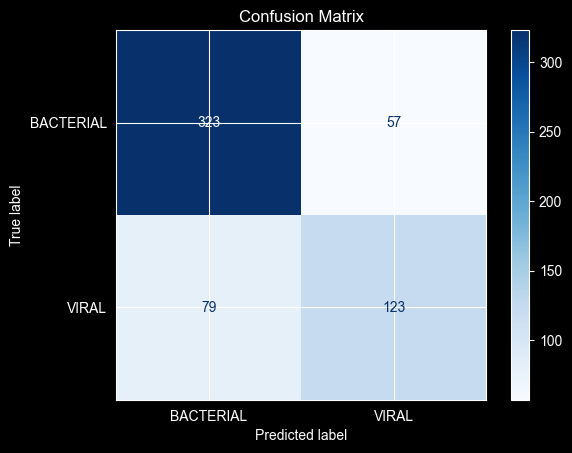

In [31]:
evaluate(model=model,
         threshold=best_threshold,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])